<a href="https://colab.research.google.com/github/mateosuster/pythonungs/blob/master/codigos/pandas/Practica_2_1_Intro_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pandas

* [Pandas](https://pandas.pydata.org/pandas-docs/stable/index.html) es una biblioteca de código abierto que proporciona estructuras de datos y herramientas de análisis de datos de alto rendimiento y fáciles de usar para el lenguaje de programación Python. Es una de las librerías más usadas para este tipo de tareas.

* Nombre derivado de "**Pan**el **Da**ta **S**ystem" (término econométrico para datasets multidimensionales).

<br>

Algunas de las principales características de esta librería son:

* Define nuevas estructuras de datos basadas en los arrays de la librería NumPy pero con nuevas funcionalidades.
* Permite acceder a los datos mediante índices o nombres para filas y columnas.
* Ofrece métodos para reordenar, dividir y combinar conjuntos de datos.

<br>

En Pandas, puedes convertir una variedad de fuentes de datos y formatos de archivo en un objeto DataFrame. Aquí hay algunos ejemplos:

1. Archivos CSV (Comma Separated Values)
2. Hojas de cálculo de Excel (.xlsx, .xls, etc.)
3. Bases de datos SQL (usando la función read_sql())
4. Archivos JSON (JavaScript Object Notation)
5. Tablas HTML (usando la función read_html())
6. Datos del portapapeles (usando la función read_clipboard())
7. Diccionarios de Python
8. Arrays NumPy


Para crear un DataFrame a partir de una fuente de datos o archivo, puedes utilizar la correspondiente función de Pandas, como `read_csv()`, `read_excel()`, `read_sql()`, `read_json()`, `read_html()`, `read_clipboard()`, `DataFrame.from_dict()` y `DataFrame.from_records(`).

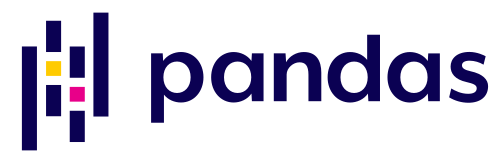


In [ ]:
#Como buena práctica (necesaria), iniciamos importando las librerías
import pandas as pd
import numpy as np

## Exploración

Vamos a analizar datos de una fuente real. Los ingresos de los funcionarios son información pública que se libera anualmente en el <a href='https://data.buenosaires.gob.ar/dataset/sueldo-funcionarios'>portal de datos abiertos</a> de GCBA.  

En general los 4 primeros pasos para analizar un data set son:
1. Leerlo
2. Consultar cuáles son las columnas
3. Extraer una muestra
4. Verificar cuántos registros tiene


### 1- Para leer el data set usamos la función de pandas `read_csv()`


Con esta función podemos leer archivos que estén en una url pública o en una ubicación del disco accesible desde la Jupyter Notebook.

In [ ]:
df = pd.read_csv('http://cdn.buenosaires.gob.ar/datosabiertos/datasets/sueldo-funcionarios/sueldo_funcionarios_2019.csv')

### 2- Consultamos las columnas


In [ ]:
df.columns

### 3- Extraemos una muestra

In [ ]:
df.sample(5)

### 4- Consultamos la cantidad de filas y de columnas

In [ ]:
# La propiedad shape nos devuelve una tupla (filas,columnas)
df.shape

## Vectorización en Pandas
Pandas es útil para trabajar sobre datos tabulares, con dos condiciones importantes:

I. Los datos se encuentran enteramente en la memoria RAM. Con lo cual, el tamaño de los datos que podemos manipular está limitado por el hardware. Como regla de pulgar, es una buena práctica no ocupar más de 1/3 de la memoria RAM de nuestro dispositivo con el dataset. Así, si estamos trabajando localmente en una notebook con 8GB de memoria RAM no es recomendable procesar datasets de más de 2.33GB.

II. En pandas, las operaciones sobre filas y columnas son, en general, eficientes porque se hacen de forma "vectorizada". En realidad esta optimización, se hace desde numpy, una librería para realizar operaciones matemáticas que se utilizó a su vez para escribir pandas.

Las operaciones vectorizadas son las que se realizan en bloque en vez de caso por caso. Las computadoras de hoy tienen la capacidad de recibir muchas instrucciones juntas y procesar varias de ellas a la vez. Por ejemplo, si nuestro hardware tiene la capacidad de procesar 4 operaciones juntas, el resultado de vectorizar una operación matemática es el siguiente:

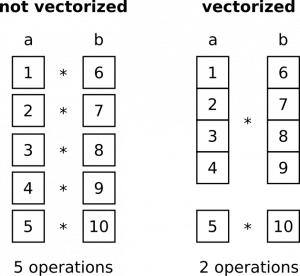

En el primer caso hay que hacer 5 operaciones y en el segundo caso sólo dos.

Es importante entender, entonces, que Pandas trabaja de esta manera y que por eso es una de las herramientas más elegidas para manipular datos en memoria.

## Los objetos fundamentales de Pandas

### Series

Las *Series* son una matriz unidimensional etiquetada capaz de contener cualquier tipo de datos (enteros, cadenas, números de punto flotante, objetos Python, etc.). Son homogéneas, es decir, sus elementos tienen que ser del mismo tipo, y su tamaño es inmutable (no se puede cambiar) aunque si su contenido.

En el fondo, podemos pensar a las series como "columnas" de una tabla que están asociadas a un índice y a un nombre. Igual que una lista común de Python es una secuencia de elementos ordenados, pero a diferencia de la lista está asociada a más información.

Son estructuras similares a los arrays de una dimensión. común

In [ ]:
# Las series se pueden crear a partir de una lista
una_serie = pd.Series(['Banana', 'Manzana', 'Naranja', 'Durazno', 'Frutilla'], dtype='string')
print(una_serie)

Métodos para ver las características de una serie:

* size :  Devuelve el número de elementos de la serie.
* index : Devuelve una lista con los nombres de las filas.
* dtype : Devuelve el tipo de datos de los elementos de la serie.

In [ ]:
# Propiedades importantes de las series
print('Tipo de objetos que tiene ', una_serie.dtype)
print('Cantidad de objetos que tiene ', una_serie.size)
print('Nombre ', una_serie.name)
print('Index ',una_serie.index)
print('Valores ',una_serie.values)


In [ ]:
#Serie creada con un diccionario
otra_serie = pd.Series({'Banana': 4,  'Manzana': 3, 'Naranja': 2})
print(otra_serie)

Para acceder a los elementos de una serie se puede realizar por índice o por posición:

* serie[i] : Devuelve el elemento que ocupa la posición i+1 en la serie s.
* serie[posiciones]: Devuelve otra serie con los elementos que ocupan las posiciones de la lista posiciones.
* serie[nombre] : Devuelve el elemento con el nombre nombre en el índice.
* serie[nombres] : Devuelve otra serie con los elementos correspondientes a los nombres indicadas en la lista nombres en el índice.

In [ ]:
print(una_serie[0])

In [ ]:
print(una_serie[0:5])
print(una_serie[[1,2]])

In [ ]:
print(otra_serie['Manzana'])

In [ ]:
print(otra_serie[['Banana','Manzana']])

### DataFrame

Un **DataFrame** es una estructura de datos bidimensional donde cada columna es un objeto de tipo Series. Todos los datos de una misma columna son del mismo tipo, y las filas son registros que pueden contener datos de distintos tipos.

Un DataFrame contiene dos índices (objeto Index), uno para las filas y otro para las columnas, y se puede acceder a sus elementos mediante los nombres de las filas y las columnas. Cada fila comparte el mismo índice.

Se puede pensar al DataFrame como una tabla SQL. En general se crean a partir de leer tablas de archivos (pueden ser en formato json, csv, xlsx, etc.) pero a veces también se crean a partir de listas de diccionarios o de otras maneras. Generalmente es el objeto pandas más utilizado.

Veamos algunas de ellas.


* Diccionario con listas:
<br>

```
{Nombre columna: [Valores]}
```

In [ ]:
name_age = {'Name' : ['Ali', 'Bill', 'David', 'Hany', 'Ibtisam'], 'Age' : [32, 55, 20, 43, 30]}
print("name_age es", type(name_age))
print(name_age)

In [ ]:
data_frame = pd.DataFrame(name_age)
print("data_frame es", type(data_frame))
data_frame.head(4)

* Lista de Diccionarios:
<br>

```
[{Columna1: valor, Columna2: valor},
{Columna1: valor, Columna2: valor}]
```

Cada elemento de la lista corresponde a una fila

In [ ]:
name_age = [{'Name': 'Ali','Age':32},
            {'Name': 'Bill','Age':55},
            {'Name': 'David','Age':20},
            {'Name': 'Hany','Age':43},
            {'Name': 'Ibtisam','Age':30}]

print("name_age es", type(name_age))
print(name_age)

In [ ]:
data_frame = pd.DataFrame(name_age)
print("data_frame es", type(data_frame))
data_frame

* Lista de listas:

<br>
[  [valor<sub>11</sub>, valor<sub>12</sub>],
<br>
[valor<sub>21</sub>, valor<sub>22</sub>],
<br>...<br>
[valor<sub>n1</sub>, valor<sub>n2</sub>] ]
<br>
<br>
  Cada lista de la superlista corresponde a una fila u observación

In [ ]:
name_age = [ ['Ali',32], ['Bill',55],
            ['David', 20], ['Hany',43],
            ['Ibtisam',30]  ]

print("name_age es", type(name_age))
print(name_age)

In [ ]:
data_frame = pd.DataFrame(name_age, columns = ["Name", "Age"]) #con columns especificamos los nombres de columnas
print("data_frame es", type(data_frame))
data_frame

### Algunos métodos útiles

Métodos para ver las características de un DataFrame:

* info : Devuelve información (número de filas, número de columnas, índices, tipo de las columnas y memoria usado) sobre el DataFrame.
* shape : Devuelve una tupla con el número de filas y columnas del DataFrame.
* size : Devuelve el número de elementos del DataFrame.
* columns : Devuelve una lista con los nombres de las columnas del DataFrame.
* index : Devuelve una lista con los nombres de las filas del DataFrame df.
* dtypes : Devuelve una serie con los tipos de datos de las columnas del DataFrame.
* head(n) : Devuelve las n primeras filas del DataFrame.
* tail(n) : Devuelve las n últimas filas del DataFrame.

In [ ]:
data_frame.info()

In [ ]:
data_frame.dtypes

In [ ]:
data_frame.columns

In [ ]:
data_frame.index

In [ ]:
data_frame.head(2)

In [ ]:
data_frame.tail(1)

In [ ]:
data_frame.shape

In [ ]:
data_frame.size

### Selección de columnas

Hay dos alternativas para seleccionar columnas de un Data Frame. Ambas producen el mismo resultado de tipo Series

In [ ]:
data_frame['Age']

In [ ]:
data_frame.Age

Esta última forma es menos utilizada, pero también es válida.

### Creación de nuevas columnas

* Podemos modificar valores de una DataFrame (o crear nuevas columnas)



In [ ]:
data_frame['Squared_Age'] = data_frame['Age'] ** 2
data_frame

La asignación no es dinámica ⚡, es decir, si yo modifico una variable, las columnas que creamos como resultado de la misma no se modifican, dado que fue asignada en un estado anterior. Por ejemplo, si yo varío la población, la densidad no se modifica.

In [ ]:
data_frame["Age"] = data_frame["Age"] * 100
data_frame

Tambien podemos ordenar las columnas de la siguiente manera

In [ ]:
data_frame[["Squared_Age","Name", "Age"]]

## Lectura de archivos

Otra manera de crear dataframes, es leyendo archivos con datos, en lugar de armarlos nosotros *a mano*. La librería pandas permite abrir y guardar los [dataframes en muchos formatos distintos](https://pandas.pydata.org/pandas-docs/stable/reference/io.html)

### Carga de Archivos

Lo primero que debemos resolver es cómo subir archivos a Google Colab. Veamos un ejemplo con los datos de [cotizaciones del dólar](https://datos.gob.ar/ru/dataset/sspm-tipo-cambio--usd---futuro-dolar). Existen múltiples maneras:

* Si tenemos una url, podemos descargarla directamente a Colab de la siguiente manera:



In [ ]:
# Descargamos un dataset público
!wget https://infra.datos.gob.ar/catalog/sspm/dataset/168/distribution/168.1/download/datos-tipo-cambio-usd-futuro-dolar-frecuencia-diaria.csv

* Otra opción es subir el archivo manualmente:

In [ ]:
from google.colab import files

uploaded=files.upload()

* Por último, es posible acceder a Google Drive en colab:

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Una vez que tenemos el archivo que queremos en colab, podemos abrirlo con la función **read_csv**

In [ ]:
dolar_df = pd.read_csv("/content/datos-tipo-cambio-usd-futuro-dolar-frecuencia-diaria.csv")
dolar_df

Algo muy importante a tener en cuenta es que los archivos cargados en el entorno de Google Colab no permanecerán allí por siempre: una vez que se apaga la máquina de Google Colab, ya sea porque salimos de la sesión o lo que fuera, los archivos cargado desaparecerán. Por lo tanto, si queremos volver a usarlos, debemos volver a cargarlos. De lo contrario obtendremos un `FileNotFoundError`.

Creación de DataFrame desde un archivo de datos

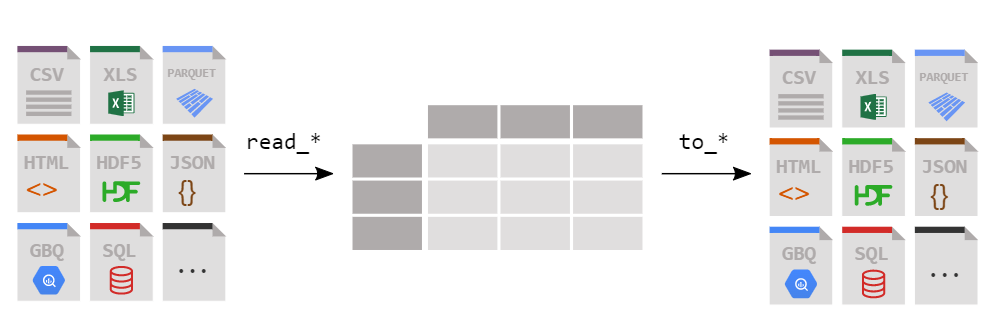

Recuerden que también podemos leer el dataframe introduciendo el URL de descarga en la función `read_csv()`, tal como hicimos al principio. El siguiente bloque de código, que es un ejemplo de ello, tiene el mismo efecto que el anterior.



In [ ]:
# dolar_df = pd.read_csv("https://infra.datos.gob.ar/catalog/sspm/dataset/168/distribution/168.1/download/datos-tipo-cambio-usd-futuro-dolar-frecuencia-diaria.csv")
# dolar_df

Repasemos algunas propiedades importantes de los dataframes.

In [ ]:
print('Columnas ', dolar_df.columns, end = "\n\n")
print('Index ', dolar_df.index, end = "\n\n")
print('Dimensiones ',dolar_df.shape, end = "\n\n")